In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
url = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt"

columns = [
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "land",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "logged_in",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "is_host_login",
    "is_guest_login",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
    "label",
    "difficulty",
]

df = pd.read_csv(url, header=None, names=columns)
print(df.shape)
print(df["label"].value_counts().head(10))


(125973, 43)
label
normal         67343
neptune        41214
satan           3633
ipsweep         3599
portsweep       2931
smurf           2646
nmap            1493
back             956
teardrop         892
warezclient      890
Name: count, dtype: int64


In [2]:
# What does normal traffic look like vs attacks?
df['is_attack'] = (df['label'] != 'normal').astype(int)
print(f"Normal: {(df['is_attack']==0).sum():,}")
print(f"Attacks: {(df['is_attack']==1).sum():,}")
print(f"\nAttack rate: {df['is_attack'].mean()*100:.1f}%")

# Look at the features
print(f"\nCategorical columns: {df.select_dtypes('object').columns.tolist()}")
print(f"Numeric columns: {len(df.select_dtypes('number').columns)}")

Normal: 67,343
Attacks: 58,630

Attack rate: 46.5%

Categorical columns: ['protocol_type', 'service', 'flag', 'label']
Numeric columns: 40


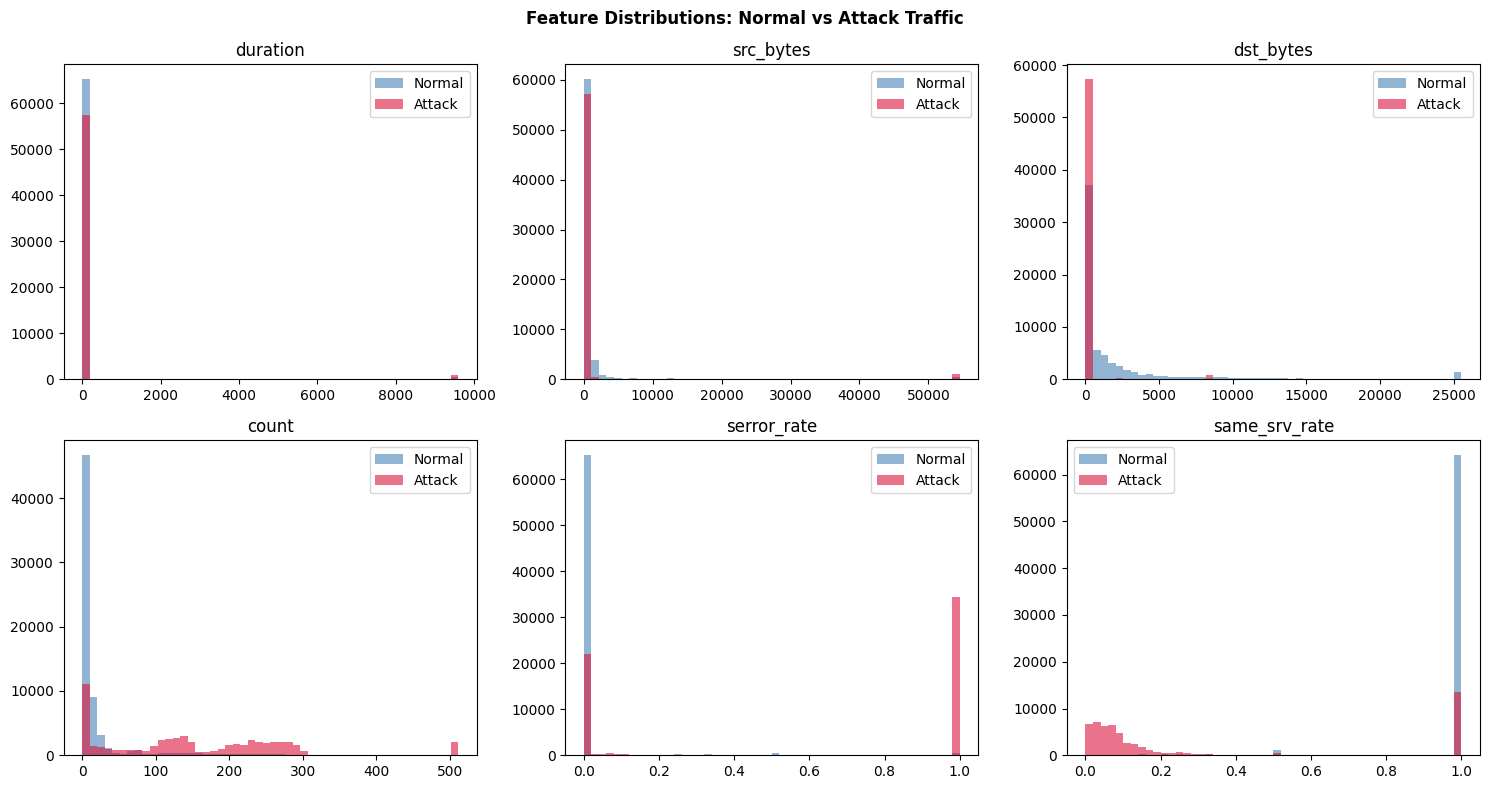

In [3]:
# Compare numeric feature distributions between normal and attack traffic
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

interesting_features = ['duration', 'src_bytes', 'dst_bytes', 'count', 'serror_rate', 'same_srv_rate']

for i, feat in enumerate(interesting_features):
    axes[i].hist(df[df['is_attack']==0][feat].clip(upper=df[feat].quantile(0.99)), 
                 bins=50, alpha=0.6, label='Normal', color='steelblue')
    axes[i].hist(df[df['is_attack']==1][feat].clip(upper=df[feat].quantile(0.99)), 
                 bins=50, alpha=0.6, label='Attack', color='crimson')
    axes[i].set_title(feat)
    axes[i].legend()

plt.suptitle('Feature Distributions: Normal vs Attack Traffic', fontweight='bold')
plt.tight_layout()
plt.show()

In [4]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

In [5]:
le = LabelEncoder()
df['protocol_type_enc'] = le.fit_transform(df['protocol_type'])
df['service_enc'] = le.fit_transform(df['service'])
df['flag_enc'] = le.fit_transform(df['flag'])

feature_cols = [c for c in df.select_dtypes('number').columns 
                if c not in ['is_attack', 'difficulty']]
X = df[feature_cols]
y = df['is_attack']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# we're only training on normal traffic
X_train_normal = X_train[y_train == 0]

scaler = StandardScaler()
X_train_normal_scaled = scaler.fit_transform(X_train_normal)
X_test_scaled = scaler.transform(X_test)
print(f"Training on {X_train_normal_scaled.shape[0]:,} normal connections only")
print(f"Test set: {X_test_scaled.shape[0]:,} connections ({y_test.sum():,} attacks)")

Training on 53,874 normal connections only
Test set: 25,195 connections (11,726 attacks)


In [6]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

Isolation Forest Classification Report:
              precision    recall  f1-score   support

      Normal       0.85      0.95      0.90     13469
      Attack       0.94      0.81      0.87     11726

    accuracy                           0.88     25195
   macro avg       0.89      0.88      0.88     25195
weighted avg       0.89      0.88      0.88     25195



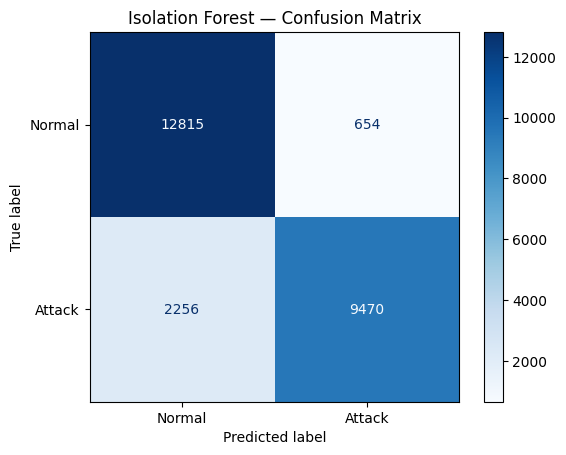

In [7]:
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42, n_jobs=-1)
iso_forest.fit(X_train_normal_scaled)
y_pred_iso = (iso_forest.predict(X_test_scaled) == -1).astype(int)
print("Isolation Forest Classification Report:")
print(classification_report(y_test, y_pred_iso, target_names=['Normal', 'Attack']))
cm = confusion_matrix(y_test, y_pred_iso)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Attack'])
disp.plot(cmap='Blues')
plt.title('Isolation Forest — Confusion Matrix')
plt.show()

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [9]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim):
        super(Autoencoder, self).__init__()
        
        # Encoder — compresses data down to 8 dimensions
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU()
        )
        
        # Decoder — reconstructs back to original dimensions
        self.decoder = nn.Sequential(
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Linear(32, input_dim)
        )
    
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

input_dim = X_train_normal_scaled.shape[1]
model = Autoencoder(input_dim)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=41, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=8, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=41, bias=True)
  )
)

Total parameters: 4,049


Epoch 10/50 — Loss: 0.284385
Epoch 20/50 — Loss: 0.213183
Epoch 30/50 — Loss: 0.199977
Epoch 40/50 — Loss: 0.135069
Epoch 50/50 — Loss: 0.112196


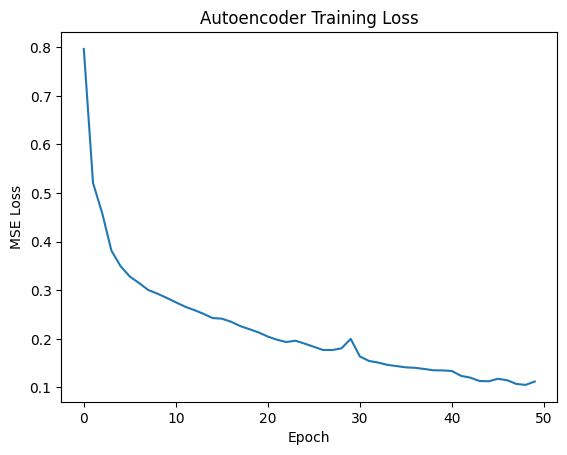

In [10]:
# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train_normal_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)

# DataLoader for batching
train_dataset = TensorDataset(X_train_tensor, X_train_tensor)  # input = target for autoencoder
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

# Training
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 50
losses = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        reconstructed = model(batch_x)
        loss = criterion(reconstructed, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.6f}')

plt.plot(losses)
plt.title('Autoencoder Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.show()

In [11]:
model.eval()
with torch.no_grad():
    reconstructed = model(X_test_tensor)
    mse_scores = torch.mean((X_test_tensor - reconstructed) ** 2, dim=1).numpy()

# Find threshold — flag top 5% reconstruction errors as anomalies
threshold = np.percentile(mse_scores, 95)
y_pred_ae = (mse_scores > threshold).astype(int)

print("=== Autoencoder Results ===")
print(classification_report(y_test, y_pred_ae, target_names=['Normal', 'Attack']))
print(f'Threshold used: {threshold:.4f}')

=== Autoencoder Results ===
              precision    recall  f1-score   support

      Normal       0.56      1.00      0.72     13469
      Attack       0.98      0.10      0.19     11726

    accuracy                           0.58     25195
   macro avg       0.77      0.55      0.45     25195
weighted avg       0.75      0.58      0.47     25195

Threshold used: 4.7750


In [12]:
from sklearn.metrics import f1_score

# Try different thresholds and see how recall and precision change
thresholds = np.percentile(mse_scores, np.arange(50, 95, 5))
results = []

for thresh in thresholds:
    y_pred = (mse_scores > thresh).astype(int)
    from sklearn.metrics import precision_score, recall_score
    results.append({
        'threshold': round(thresh, 4),
        'percentile': np.arange(50, 95, 5)[list(thresholds).index(thresh)],
        'precision': round(precision_score(y_test, y_pred), 3),
        'recall': round(recall_score(y_test, y_pred), 3),
        'f1': round(f1_score(y_test, y_pred), 3)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 threshold  percentile  precision  recall    f1
    0.2103          50      0.893   0.959 0.925
    0.4230          55      0.950   0.919 0.934
    0.7219          60      0.975   0.838 0.902
    1.6954          65      0.988   0.743 0.848
    2.6450          70      0.991   0.639 0.777
    2.9805          75      0.992   0.533 0.693
    3.3152          80      0.991   0.426 0.596
    3.8085          85      0.989   0.319 0.482
    4.3343          90      0.986   0.212 0.349


=== Autoencoder Results (Optimal Threshold) ===
              precision    recall  f1-score   support

      Normal       0.93      0.96      0.94     13469
      Attack       0.95      0.92      0.93     11726

    accuracy                           0.94     25195
   macro avg       0.94      0.94      0.94     25195
weighted avg       0.94      0.94      0.94     25195


=== Model Comparison ===
                    Isolation Forest  Autoencoder (tuned)
Metric                                                   
Precision (Attack)            0.9354               0.9503
Recall (Attack)               0.8076               0.9188
F1 (Attack)                   0.8668               0.9343
Weighted F1                   0.8835               0.9398


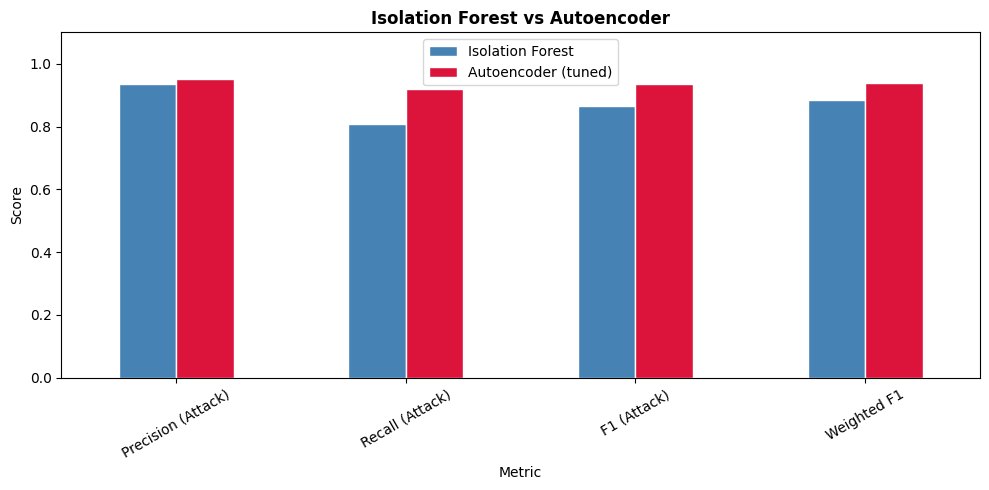

In [13]:
# Rerun autoencoder predictions with optimal threshold
best_threshold = np.percentile(mse_scores, 55)
y_pred_ae_optimal = (mse_scores > best_threshold).astype(int)

print("=== Autoencoder Results (Optimal Threshold) ===")
print(classification_report(y_test, y_pred_ae_optimal, target_names=['Normal', 'Attack']))

# Final comparison
from sklearn.metrics import precision_score, recall_score

comparison = pd.DataFrame({
    'Metric': ['Precision (Attack)', 'Recall (Attack)', 'F1 (Attack)', 'Weighted F1'],
    'Isolation Forest': [
        precision_score(y_test, y_pred_iso),
        recall_score(y_test, y_pred_iso),
        f1_score(y_test, y_pred_iso),
        f1_score(y_test, y_pred_iso, average='weighted')
    ],
    'Autoencoder (tuned)': [
        precision_score(y_test, y_pred_ae_optimal),
        recall_score(y_test, y_pred_ae_optimal),
        f1_score(y_test, y_pred_ae_optimal),
        f1_score(y_test, y_pred_ae_optimal, average='weighted')
    ]
}).set_index('Metric').round(4)

print("\n=== Model Comparison ===")
print(comparison.to_string())

# Visualise
comparison.plot(kind='bar', figsize=(10, 5), color=['steelblue', 'crimson'], edgecolor='white')
plt.title('Isolation Forest vs Autoencoder', fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=30)
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import joblib
import torch

# Save scaler
joblib.dump(scaler, 'scaler.pkl')

# Save Isolation Forest
joblib.dump(iso_forest, 'isolation_forest.pkl')

# Save Autoencoder
torch.save(model.state_dict(), 'autoencoder.pth')

# Save test data for the sample explorer
test_df = pd.DataFrame(X_test_scaled, columns=feature_cols)
test_df['true_label'] = y_test.values
test_df['mse_score'] = mse_scores
test_df.to_csv('test_samples.csv', index=False)

# Save the optimal threshold and input dim
joblib.dump({
    'threshold': best_threshold,
    'input_dim': input_dim,
    'feature_cols': feature_cols
}, 'model_config.pkl')

print('All files saved ✅')